<a href="https://www.kaggle.com/code/josuafrino/ai-impact-on-students?scriptVersionId=334875574" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This project aims to analyze how artificial intelligence technology affects students' experiences, learning outcomes, or behavior.

In [1]:
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Dataset Overview

In [2]:
df = pd.read_csv("/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv")

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
df.tail() 

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [4]:
df.shape

(50000, 16)

In [5]:
df.info()    

# Display dataset information:
                              # Number of rows
                              # Number of columns
                              # Data types
                              # Non-null values
                              # Memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [6]:
list(df.columns)

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [7]:
df.dtypes 

Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [8]:
df.sample(5) 

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
33770,133771,Business,Junior,3.772,2.91,Ideation,Beginner,3,False,21.74,2,Allowed_With_Citation,4,4.000,84.00,Low
11045,111046,Business,Sophomore,3.424,18.08,Ideation,Advanced,4,True,10.47,6,Allowed_With_Citation,6,4.000,54.76,Medium
12777,112778,Medical,Junior,2.903,2.28,Direct_Answer_Generation,Beginner,3,False,17.90,2,Actively_Encouraged,5,3.009,70.25,Medium
9387,109388,STEM,Junior,3.199,21.67,Ideation,Intermediate,3,True,1.00,3,Allowed_With_Citation,2,3.297,87.39,Medium
8274,108275,Business,Freshman,3.563,17.48,Ideation,Beginner,2,True,8.58,2,Allowed_With_Citation,5,3.656,74.65,Low


In [9]:
df.size    # Return the total number of elements in the dataset.

# Formula:
#         Rows × Columns

# Example:
#         1000 × 15 = 15000

800000

In [10]:
df.ndim    # Return the number of dimensions of the dataset.

# Because a DataFrame is two-dimensional (rows and columns).

2

In [11]:
df.memory_usage(deep = True)   

# Display the memory consumed by each column in the dataset.

# Useful for:
#            Large datasets
#            Memory optimization
#            Performance analysis

Index                             132
Student_ID                     400000
Major_Category                2779544
Year_of_Study                 2816502
Pre_Semester_GPA               400000
Weekly_GenAI_Hours             400000
Primary_Use_Case              3399550
Prompt_Engineering_Skill      2920784
Tool_Diversity                 400000
Paid_Subscription               50000
Traditional_Study_Hours        400000
Perceived_AI_Dependency        400000
Institutional_Policy          3362356
Anxiety_Level_During_Exams     400000
Post_Semester_GPA              400000
Skill_Retention_Score          400000
Burnout_Risk_Level            2675919
dtype: int64

**Missing Values Analysis**

In [12]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [13]:
df.duplicated().sum() 

np.int64(0)

**Descriptive Statistics**

In [14]:
df.describe()   

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [15]:
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [16]:
df.describe(include="object")

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50000,50000,50000,50000,50000,50000
unique,5,5,5,3,3,3
top,STEM,Junior,Debugging/Troubleshooting,Beginner,Allowed_With_Citation,Medium
freq,15059,11045,12295,18495,25224,21144


Categorical Columns Summary¶
The dataset contains 6 categorical (object) columns, providing information about students' academic background, AI usage, institutional policies, and burnout risk.

Key Observations
STEM is the most common major category with 15,059 students.
Junior is the most frequent year of study with 11,045 students.
Debugging/Troubleshooting is the most common use case of Generative AI (12,295 students).
Most students have Beginner prompt engineering skills (18,495 students).
The most common institutional policy is Allowed_With_Citation (25,224 students).
Most students fall into the Medium burnout risk category (21,144 students).
Conclusion
The categorical features show the dominant categories within the dataset and provide valuable insights into students' AI usage patterns, academic background, institutional policies, and burnout levels. These findings will support further exploratory data analysis and visualization.

In [17]:
df.nunique()  

Student_ID                    50000
Major_Category                    5
Year_of_Study                     5
Pre_Semester_GPA               2389
Weekly_GenAI_Hours             3566
Primary_Use_Case                  5
Prompt_Engineering_Skill          3
Tool_Diversity                    5
Paid_Subscription                 2
Traditional_Study_Hours        2516
Perceived_AI_Dependency          10
Institutional_Policy              3
Anxiety_Level_During_Exams       10
Post_Semester_GPA              2269
Skill_Retention_Score          5872
Burnout_Risk_Level                3
dtype: int64

**Categorical Variables Analysis**

In [18]:
df["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [19]:
df["Year_of_Study"].value_counts()

Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

In [20]:
df["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

**Correlation Analysis**

In [21]:
df.corr(numeric_only=True)   # Calculate the correlation matrix for numerical columns

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Student_ID,1.000000,0.002275,0.001577,-0.001187,-0.000319,0.000648,0.002768,0.009670,-0.000602,-0.001737
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.001027,-0.004620,0.000701,-0.000667,0.926781,0.099019
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,0.196943,-0.157368,0.665479,0.269080,-0.018600,-0.118099
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.005803,0.003565,0.006019,0.003189,0.025265,0.196952
Paid_Subscription,-0.000319,-0.001027,0.196943,0.005803,1.000000,-0.035329,0.131033,0.065845,0.005528,-0.024083
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,-0.035329,1.000000,-0.102625,-0.040935,0.137653,0.147565
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,0.131033,-0.102625,1.000000,0.307620,-0.014180,-0.084324
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,0.065845,-0.040935,0.307620,1.000000,-0.015909,-0.041556
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.005528,0.137653,-0.014180,-0.015909,1.000000,0.169616
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,-0.024083,0.147565,-0.084324,-0.041556,0.169616,1.000000


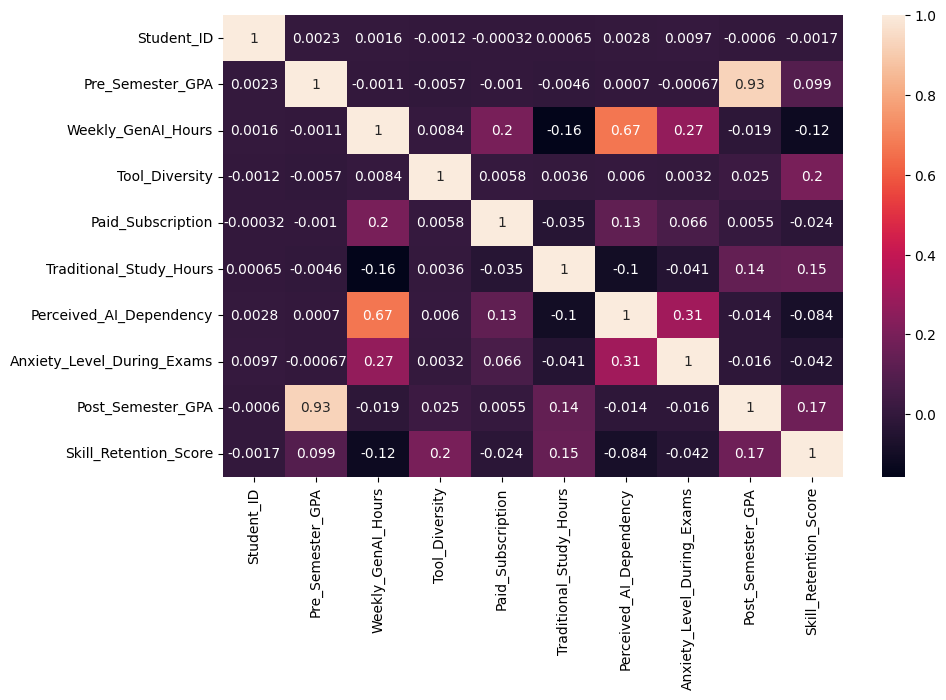

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.show()

# Data Visualization

1. Major Category Distribution

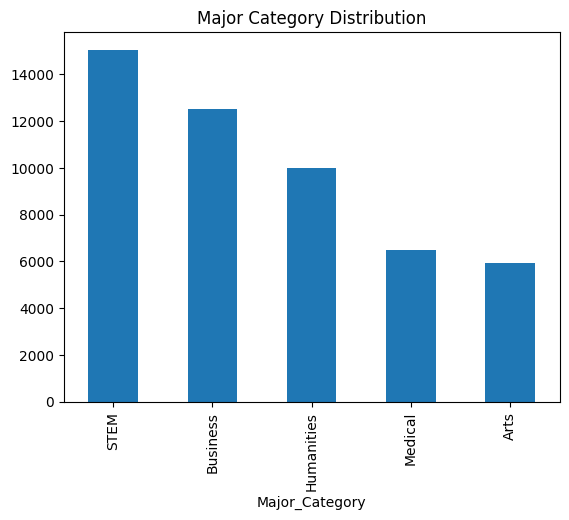

In [23]:
df["Major_Category"].value_counts().plot(kind="bar")
plt.title("Major Category Distribution")
plt.show()


2. Year of Study Distribution

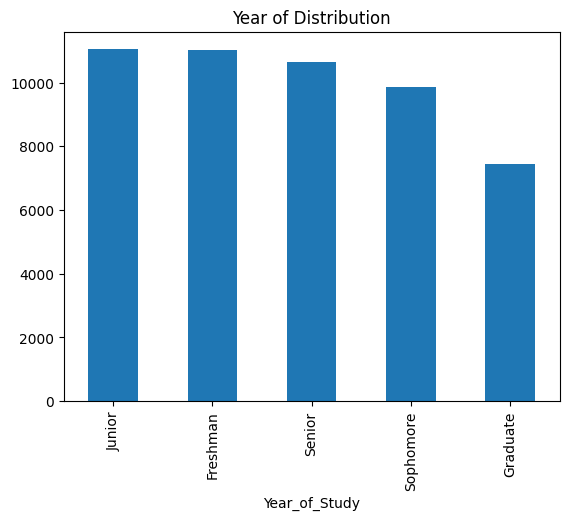

In [24]:
df["Year_of_Study"].value_counts().plot(kind="bar")
plt.title("Year of Distribution")
plt.show()

3. Primary Use Case Distribution

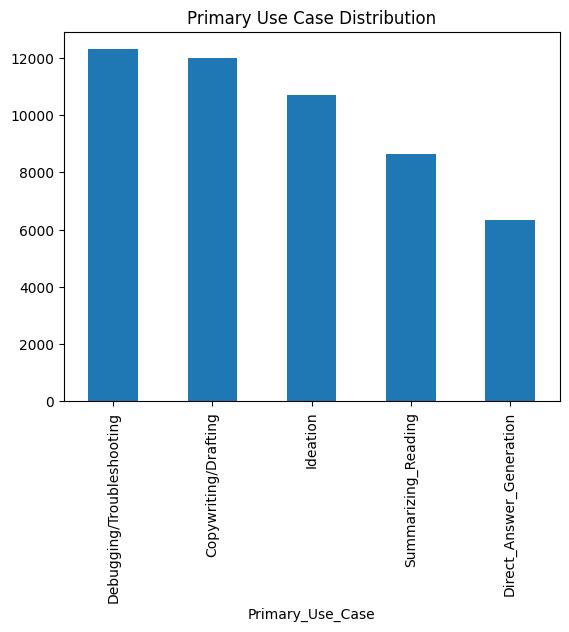

In [25]:
df["Primary_Use_Case"].value_counts().plot(kind="bar")
plt.title("Primary Use Case Distribution")
plt.show()

4. Histogram for Numerical Columns

In [26]:
df.select_dtypes(include="number").columns

Index(['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score'],
      dtype='object')

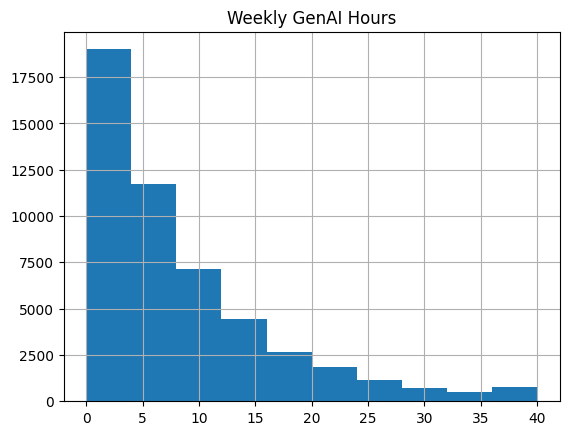

In [27]:
df["Weekly_GenAI_Hours"].hist()
plt.title("Weekly GenAI Hours")
plt.show()

In [28]:
# Which major uses GenAI the most?

df.groupby("Major_Category")["Weekly_GenAI_Hours"].mean().sort_values(ascending=False)

Major_Category
STEM          10.488609
Business       8.275898
Medical        7.546728
Arts           7.271702
Humanities     6.770144
Name: Weekly_GenAI_Hours, dtype: float64

In [29]:
# Why do students use GenAI most?

df.groupby("Primary_Use_Case")["Weekly_GenAI_Hours"].mean()

Primary_Use_Case
Copywriting/Drafting         7.627983
Debugging/Troubleshooting    9.401141
Direct_Answer_Generation     8.455863
Ideation                     8.398023
Summarizing_Reading          8.170452
Name: Weekly_GenAI_Hours, dtype: float64

In [30]:
# Which major has the highest GPA?

df.groupby("Major_Category")["Pre_Semester_GPA"].mean().sort_values(ascending=False)

Major_Category
Medical       3.151769
Humanities    3.147850
Arts          3.146786
STEM          3.145852
Business      3.141760
Name: Pre_Semester_GPA, dtype: float64

In [31]:
# Which year has the highest Anxiety level?

df.groupby("Year_of_Study")["Anxiety_Level_During_Exams"].mean()

Year_of_Study
Freshman     4.279576
Graduate     4.230686
Junior       4.263196
Senior       4.272146
Sophomore    4.298073
Name: Anxiety_Level_During_Exams, dtype: float64

In [32]:
# Which major has the highest Post Semester GPA?

df.groupby("Major_Category")["Post_Semester_GPA"].mean().sort_values(ascending=False)

Major_Category
STEM          3.363154
Medical       3.353168
Humanities    3.345825
Arts          3.343688
Business      3.336085
Name: Post_Semester_GPA, dtype: float64

In [33]:
# Which year uses GenAI the most?

df.groupby("Year_of_Study")["Weekly_GenAI_Hours"].mean().sort_values(ascending=False)

Year_of_Study
Senior       8.459251
Freshman     8.446962
Sophomore    8.446249
Graduate     8.406052
Junior       8.376325
Name: Weekly_GenAI_Hours, dtype: float64

In [34]:
# Burnout Risk vs Anxiety

df.groupby("Burnout_Risk_Level")["Anxiety_Level_During_Exams"].mean().sort_values(ascending=False)

Burnout_Risk_Level
High      4.889325
Medium    4.170450
Low       3.928462
Name: Anxiety_Level_During_Exams, dtype: float64

**1. Boxplots**

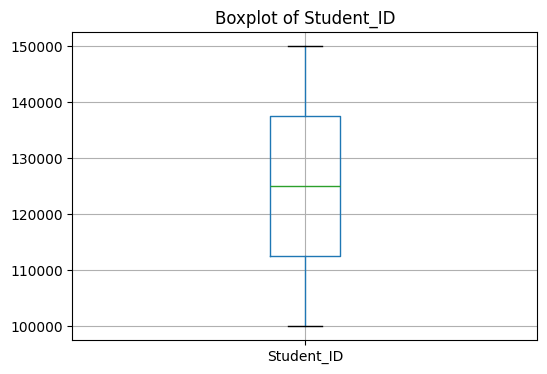

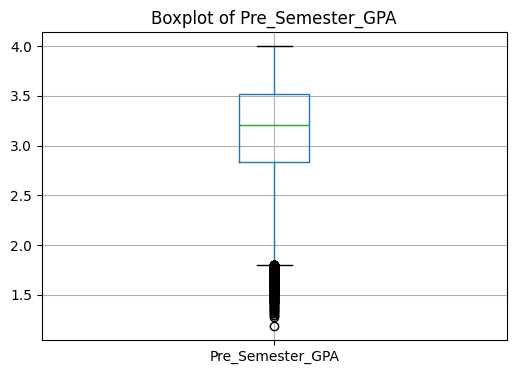

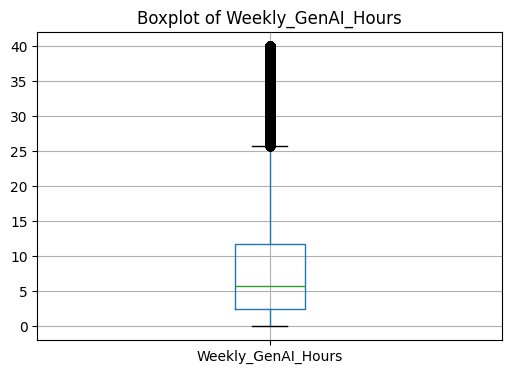

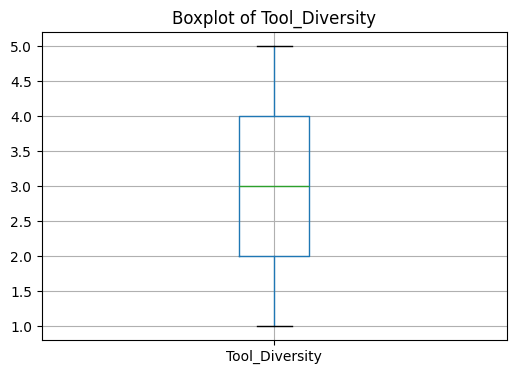

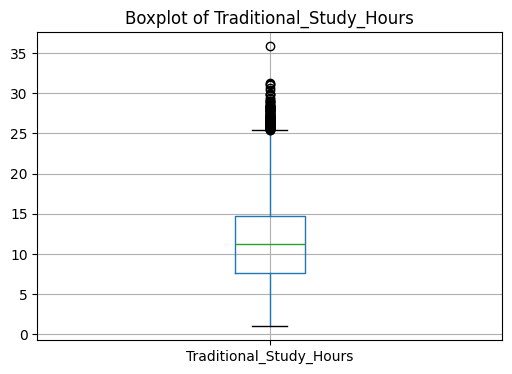

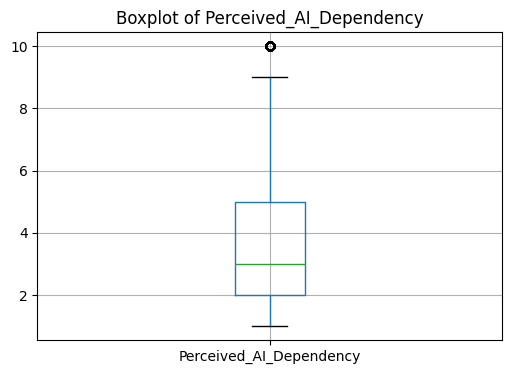

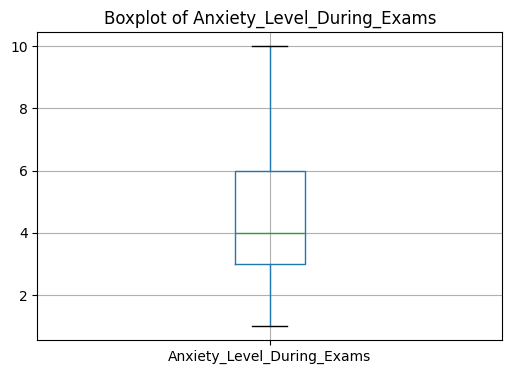

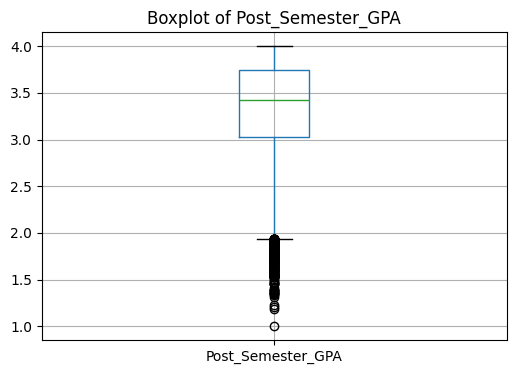

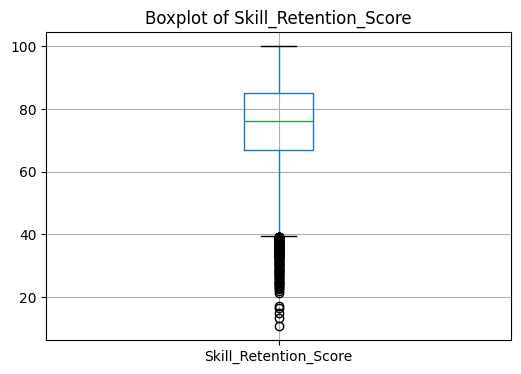

In [35]:
import matplotlib.pyplot as plt

numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

**2. Histograms (All Numerical Columns)**

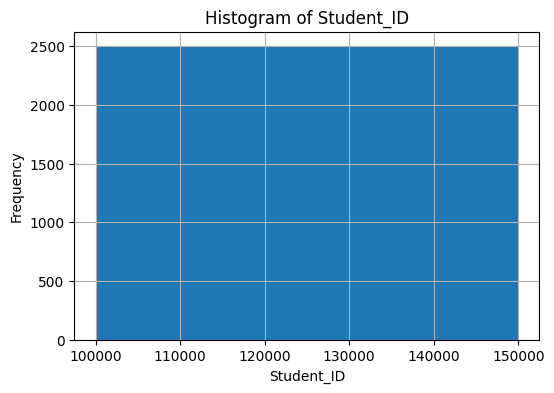

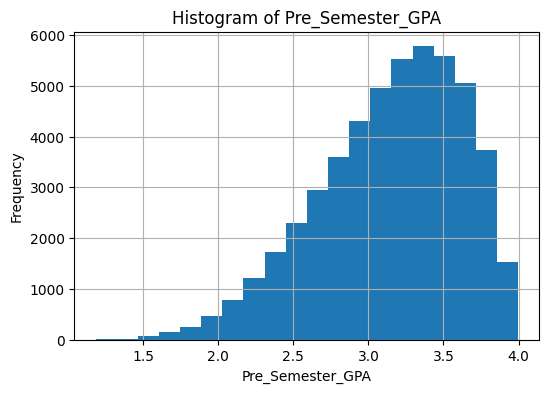

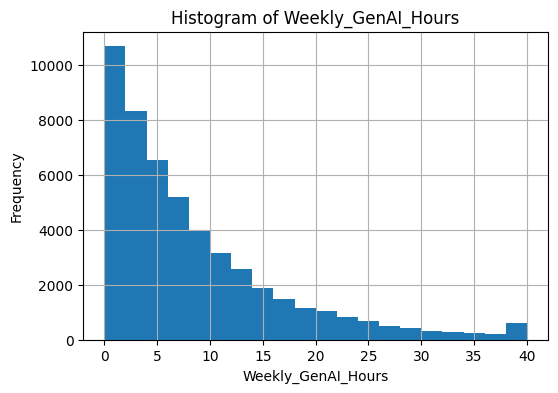

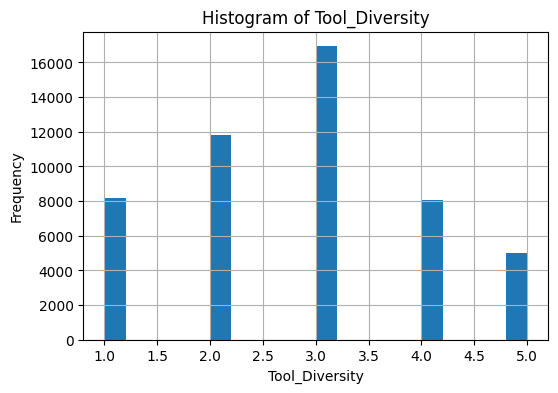

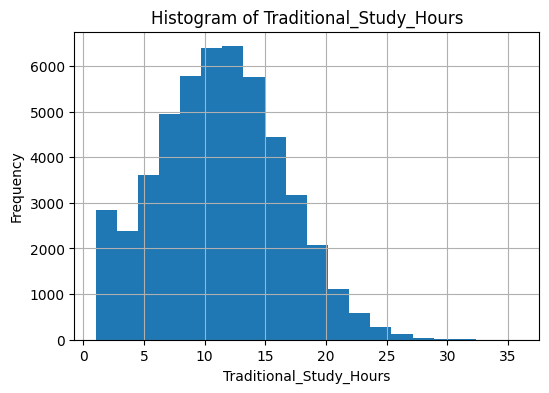

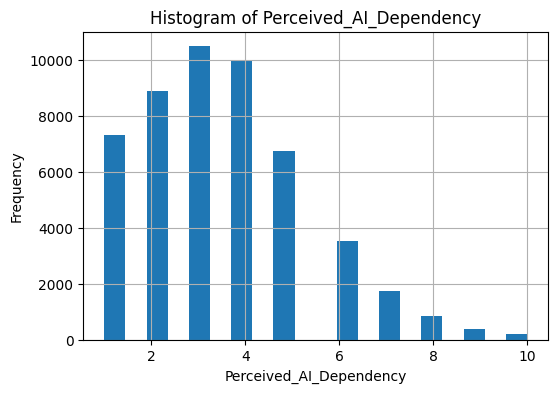

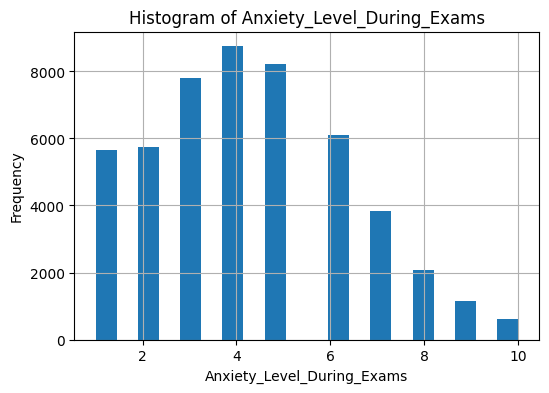

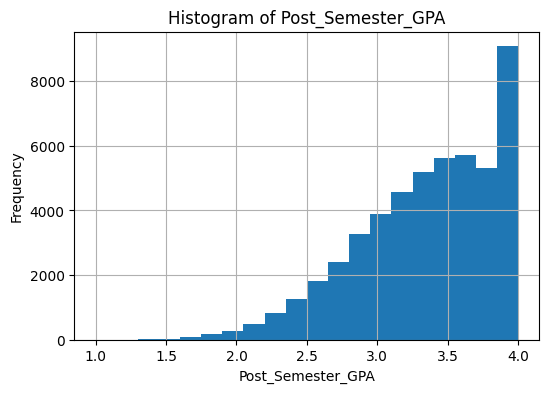

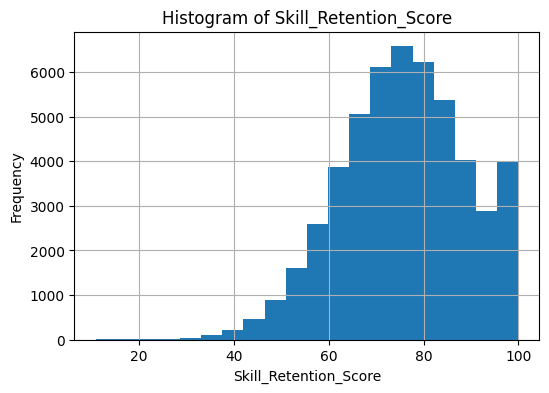

In [36]:
numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**3. Scatterplots**

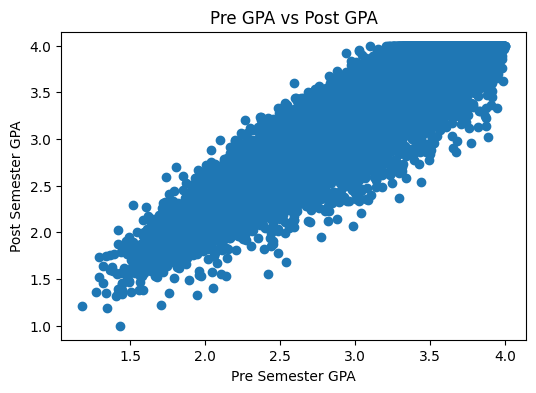

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["Pre_Semester_GPA"], df["Post_Semester_GPA"])
plt.xlabel("Pre Semester GPA")
plt.ylabel("Post Semester GPA")
plt.title("Pre GPA vs Post GPA")
plt.show()

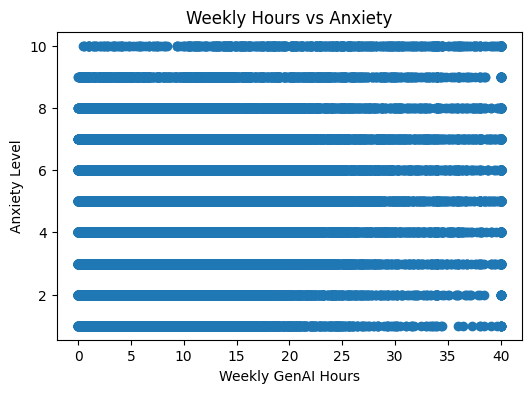

In [38]:
plt.figure(figsize=(6,4))
plt.scatter(df["Weekly_GenAI_Hours"], df["Anxiety_Level_During_Exams"])
plt.xlabel("Weekly GenAI Hours")
plt.ylabel("Anxiety Level")
plt.title("Weekly Hours vs Anxiety")
plt.show()


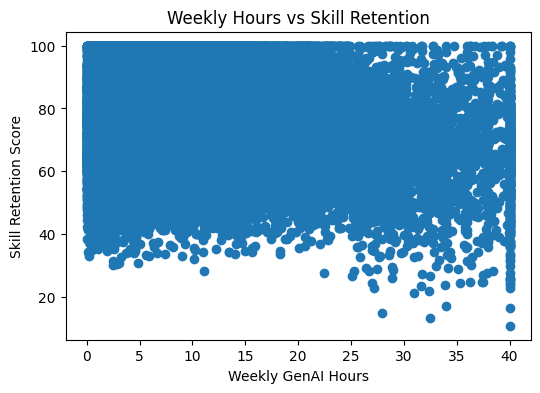

In [39]:
plt.figure(figsize=(6,4))
plt.scatter(df["Weekly_GenAI_Hours"], df["Skill_Retention_Score"])
plt.xlabel("Weekly GenAI Hours")
plt.ylabel("Skill Retention Score")
plt.title("Weekly Hours vs Skill Retention")
plt.show()

**4. Countplots**

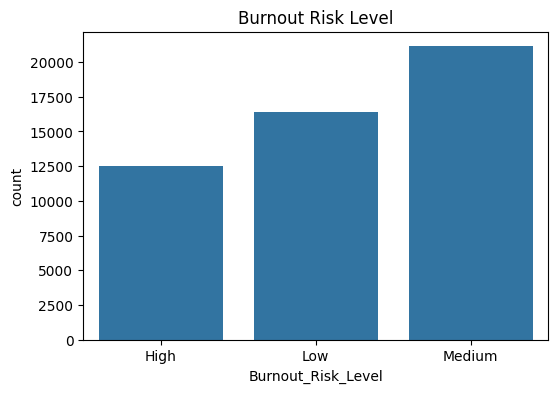

In [40]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Burnout_Risk_Level")
plt.title("Burnout Risk Level")
plt.show()

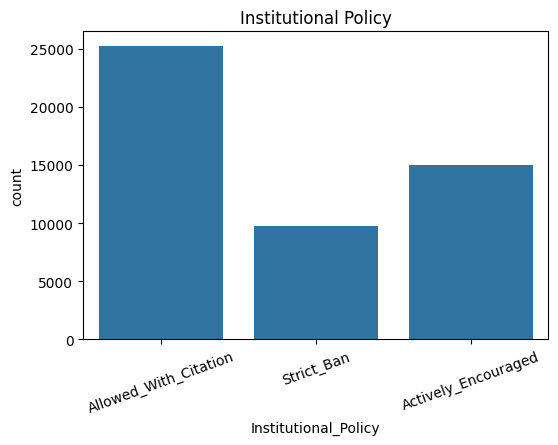

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Institutional_Policy")
plt.title("Institutional Policy")
plt.xticks(rotation=20)
plt.show()

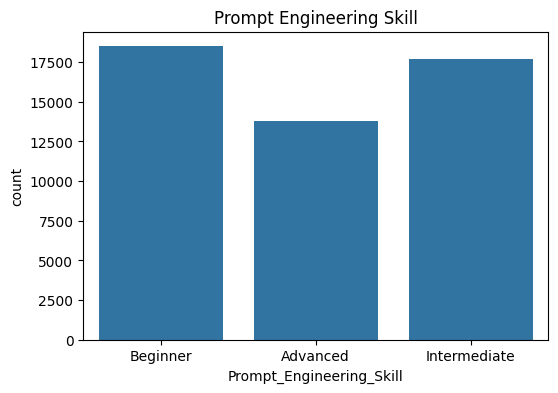

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Prompt_Engineering_Skill")
plt.title("Prompt Engineering Skill")
plt.show()

**5. Pie Charts**

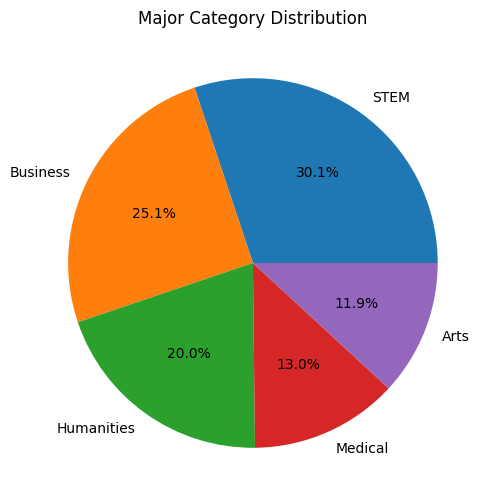

In [43]:
df["Major_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Major Category Distribution")
plt.ylabel("")
plt.show()

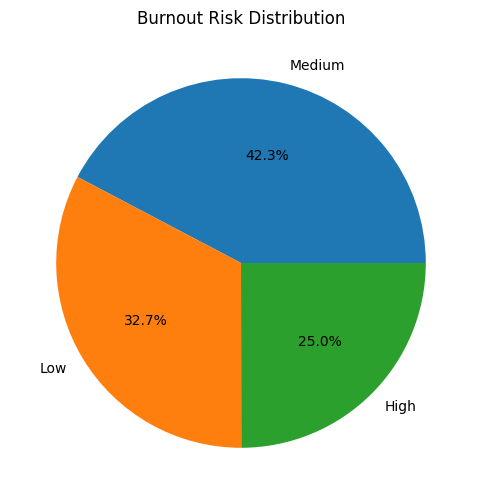

In [44]:
df["Burnout_Risk_Level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Burnout Risk Distribution")
plt.ylabel("")
plt.show()

**6. Pairplot**

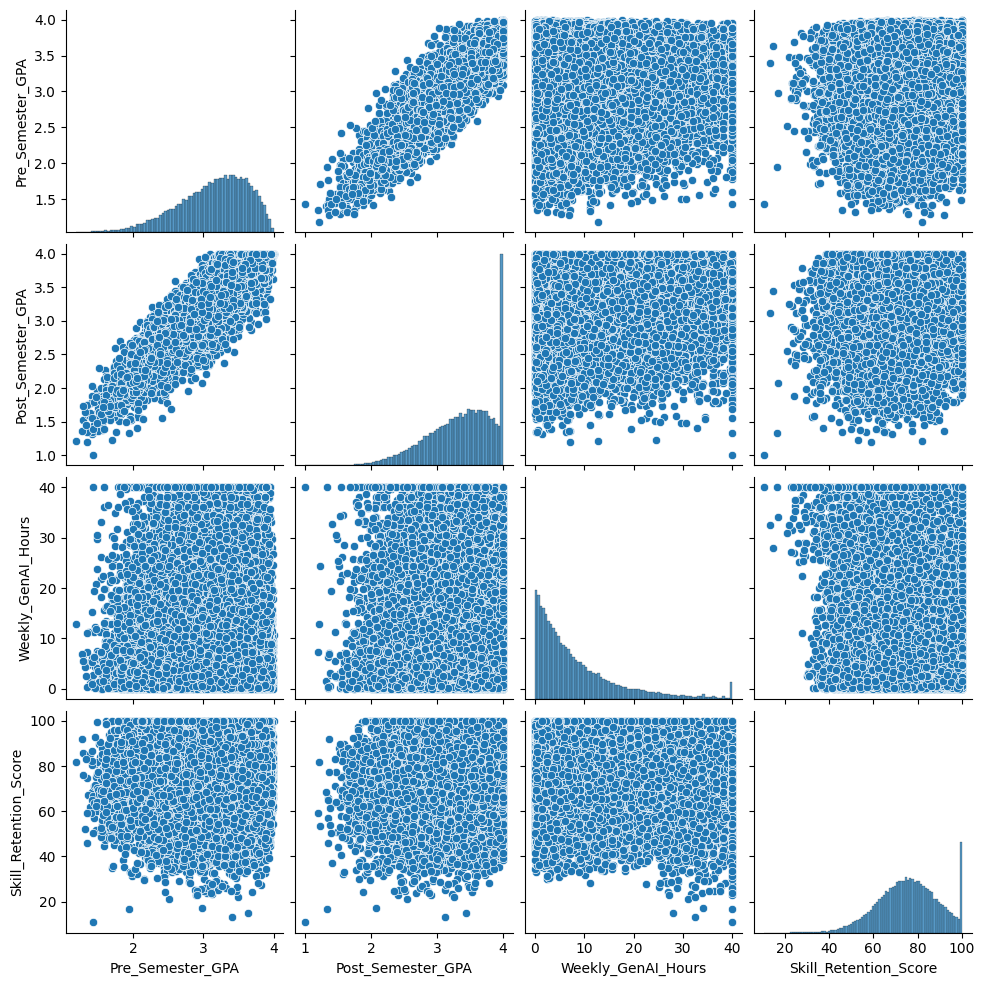

In [45]:
sns.pairplot(
    df[
        [
            "Pre_Semester_GPA",
            "Post_Semester_GPA",
            "Weekly_GenAI_Hours",
            "Skill_Retention_Score"
        ]
    ]
)

plt.show()

**7. Skewness**

In [46]:
df.skew(numeric_only=True)

Student_ID                    0.000000
Pre_Semester_GPA             -0.602043
Weekly_GenAI_Hours            1.609772
Tool_Diversity                0.166799
Paid_Subscription             0.311396
Traditional_Study_Hours       0.130072
Perceived_AI_Dependency       0.655365
Anxiety_Level_During_Exams    0.361730
Post_Semester_GPA            -0.675059
Skill_Retention_Score        -0.215181
dtype: float64

**8. Kurtosis**

In [47]:
df.kurt(numeric_only=True)

Student_ID                   -1.200000
Pre_Semester_GPA             -0.104626
Weekly_GenAI_Hours            2.556943
Tool_Diversity               -0.743679
Paid_Subscription            -1.903109
Traditional_Study_Hours      -0.304698
Perceived_AI_Dependency       0.262690
Anxiety_Level_During_Exams   -0.407925
Post_Semester_GPA            -0.033962
Skill_Retention_Score        -0.216551
dtype: float64

**9. Covariance Matrix**

In [48]:
df.cov(numeric_only=True)

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Student_ID,2.083375e+08,15.721648,188.246457,-20.358017,-2.273265,48.203096,72.756235,299.248085,-4.308448,-332.977079
Pre_Semester_GPA,1.572165e+01,0.229301,-0.004293,-0.003226,-0.000243,-0.011408,0.000611,-0.000684,0.219976,0.629756
Weekly_GenAI_Hours,1.882465e+02,-0.004293,68.384460,0.082628,0.804621,-6.710324,10.020236,4.770873,-0.076242,-12.971080
Tool_Diversity,-2.035802e+01,-0.003226,0.082628,1.411392,0.003406,0.021839,0.013021,0.008122,0.014878,3.107672
Paid_Subscription,-2.273265e+00,-0.000243,0.804621,0.003406,0.244088,-0.090002,0.117875,0.069748,0.001354,-0.158030
Traditional_Study_Hours,4.820310e+01,-0.011408,-6.710324,0.021839,-0.090002,26.588730,-0.963533,-0.452570,0.351828,10.106104
Perceived_AI_Dependency,7.275624e+01,0.000611,10.020236,0.013021,0.117875,-0.963533,3.315358,1.200933,-0.012798,-2.039244
Anxiety_Level_During_Exams,2.992481e+02,-0.000684,4.770873,0.008122,0.069748,-0.452570,1.200933,4.597021,-0.016907,-1.183365
Post_Semester_GPA,-4.308448e+00,0.219976,-0.076242,0.014878,0.001354,0.351828,-0.012798,-0.016907,0.245691,1.116638
Skill_Retention_Score,-3.329771e+02,0.629756,-12.971080,3.107672,-0.158030,10.106104,-2.039244,-1.183365,1.116638,176.401597


**10. Missing Value Heatmap**

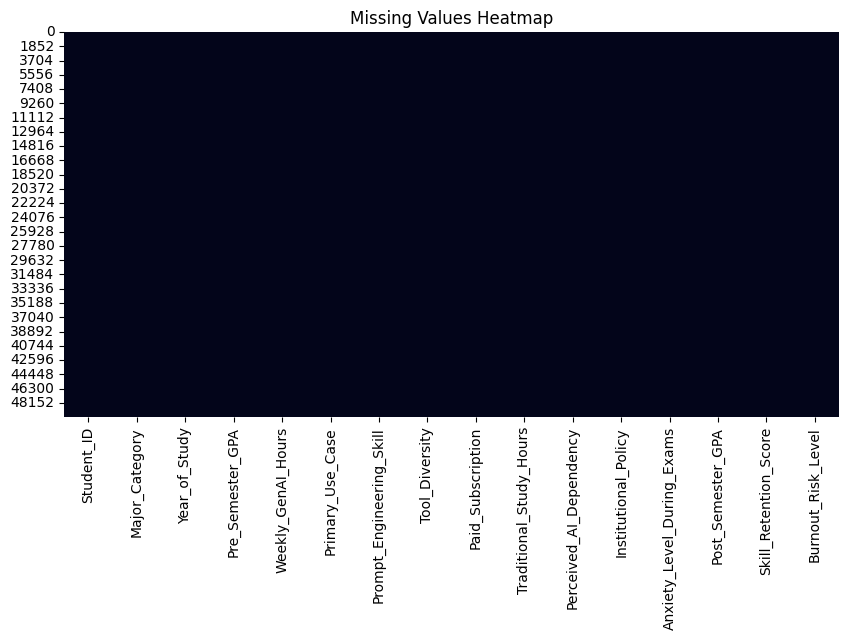

In [49]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Insights and Findings
1. STEM students spend the highest average time using Generative AI tools (10.49 hours/week), while Humanities students spend the least (6.77 hours/week).
2. Debugging and Troubleshooting is the most time-intensive use case of Generative AI.
3. Medical students have the highest average Pre-Semester GPA.
4. STEM students achieve the highest average Post-Semester GPA.
5. Sophomore students report the highest average anxiety levels during exams.
6. Senior students spend the most time using Generative AI tools.
7. Students with High Burnout Risk also have the highest average anxiety levels.
8. Most numerical variables show slight positive skewness, indicating a few high-value observations.
9. The covariance matrix suggests positive relationships between several academic performance variables.
10. No missing values were found in the dataset, indicating good data quality for analysis.


# Conclusion
This Exploratory Data Analysis (EDA) provides valuable insights into how students use Generative AI and its relationship with academic performance, anxiety, and burnout.

The analysis shows that STEM students are the most active users of Generative AI tools, while Medical students have the highest average academic performance before the semester. Students with higher burnout risk also tend to experience higher anxiety levels during exams.

Overall, the dataset is clean, contains no missing values, and is suitable for further Machine Learning modeling and predictive analysis.

# Recommendations

1. Encourage responsible and balanced use of Generative AI for academic learning.
2. Provide AI literacy programs to help students use AI tools effectively and ethically.
3. Monitor students with high burnout and anxiety through counseling and wellness programs.
4. Promote AI as a learning assistant rather than a replacement for critical thinking.
5. Encourage students to combine traditional study methods with AI-assisted learning.
6. Introduce institution-level policies for ethical AI usage in education.
7. Conduct regular assessments to measure the long-term impact of AI on learning outcomes.
